# StyleCLIP mapper - training a facial edit on a frozen StyleGAN2

Training a small network (**`LatentMapper`**) that takes a `W+` latent and returns the offset `delta_wplus` which makes that face **with glasses**. The pretrained StyleGAN2 stays frozen - only the mapper learns.

Supervision comes from **CLIP**: the edit's shift in CLIP *image* space (`delta_I`) should point the same way as the shift between two text prompts in CLIP *text* space (`delta_T`).

In [2]:
import os
import sys
import numpy as np
import torch
import torch.nn.functional as F
import torch.utils.data as data
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from latent_mapper import LatentMapper, CLIPEmbedder, clip_direction_loss, magnitude_loss

from stylegan_utils import add_stylegan_repo, load_stylegan2_ffhq256, tensor2img, img2tensor, sample_wplus

In [3]:
add_stylegan_repo('./stylegan2-ada-pytorch')

device = torch.device('cuda:0')
G = load_stylegan2_ffhq256(device)
print('num_ws:', G.num_ws, '| z_dim:', G.z_dim)

num_ws: 14 | z_dim: 512


In [4]:
clip = CLIPEmbedder(device)

TEXT_BEFORE = 'a photo of a person'
TEXT_AFTER  = 'a photo of a person with glasses'

delta_T = clip.text_direction(TEXT_BEFORE, TEXT_AFTER)
print('delta_T:', tuple(delta_T.shape))

delta_T: (1, 512)


In [16]:
# Precomputation a pool of W+ latents and the CLIP embedding of the face each one produces. 
# Only the before-embeddings can be cached;
# the after-embeddings depend on the mapper and must be recomputed every step.

# Latents are drawn with a random truncation_psi per batch, which spreads them across W+ instead 
# of clustering near w_avg - the mapper should work for faces far from average too.

NUM_LATENTS = 10_000
BATCH = 16

wplus_pool = sample_wplus(G, NUM_LATENTS, device, truncation_psi=None, seed=42, batch_size=BATCH)
print('wplus pool:', tuple(wplus_pool.shape))

emb_pool = []
with torch.no_grad():
    for i in tqdm(range(0, NUM_LATENTS, BATCH)):
        w = wplus_pool[i:i + BATCH].to(device)
        img = G.synthesis(w, noise_mode='const')
        emb_pool.append(clip.embed_image(img).cpu())
emb_pool = torch.cat(emb_pool)
print('clip embeddings:', tuple(emb_pool.shape))

In [6]:
train_ds = data.TensorDataset(wplus_pool.cpu(), emb_pool)
train_dl = data.DataLoader(train_ds, batch_size=8, shuffle=True, drop_last=True)

def infinite(loader):
    while True:
        for batch in loader:
            yield batch
train_it = infinite(train_dl)

Loss = **cosine** (align `delta_I` with `delta_T`) + **magnitude** (keep the `W+` offset small). The magnitude term matters: without it the mapper is free to wander far in `W+` and changes the person's identity, not just their expression.

In [17]:
mapper = LatentMapper(num_latents=G.num_ws).train().to(device)
optimizer = torch.optim.Adam(mapper.parameters(), lr=2e-3)

NUM_STEPS = 4_000
LAMBDA_MAGN = 0.05

hist_cos, hist_magn = [], []
pbar = tqdm(range(NUM_STEPS))
for _ in pbar:
    wplus, emb_before = next(train_it)
    wplus, emb_before = wplus.to(device), emb_before.to(device)

    delta_wplus = mapper(wplus)
    img_after = G.synthesis(wplus + delta_wplus, noise_mode='const')
    emb_after = clip.embed_image(img_after)

    delta_I = emb_after - emb_before
    loss_cos = clip_direction_loss(delta_I, delta_T)
    loss_magn = magnitude_loss(delta_wplus)
    loss = loss_cos + LAMBDA_MAGN * loss_magn

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    hist_cos.append(loss_cos.item())
    hist_magn.append(loss_magn.item())
    pbar.set_postfix({'cos': round(loss_cos.item(), 4), 'magn': round(loss_magn.item(), 4)})
    
pbar.close()
mapper = mapper.eval()

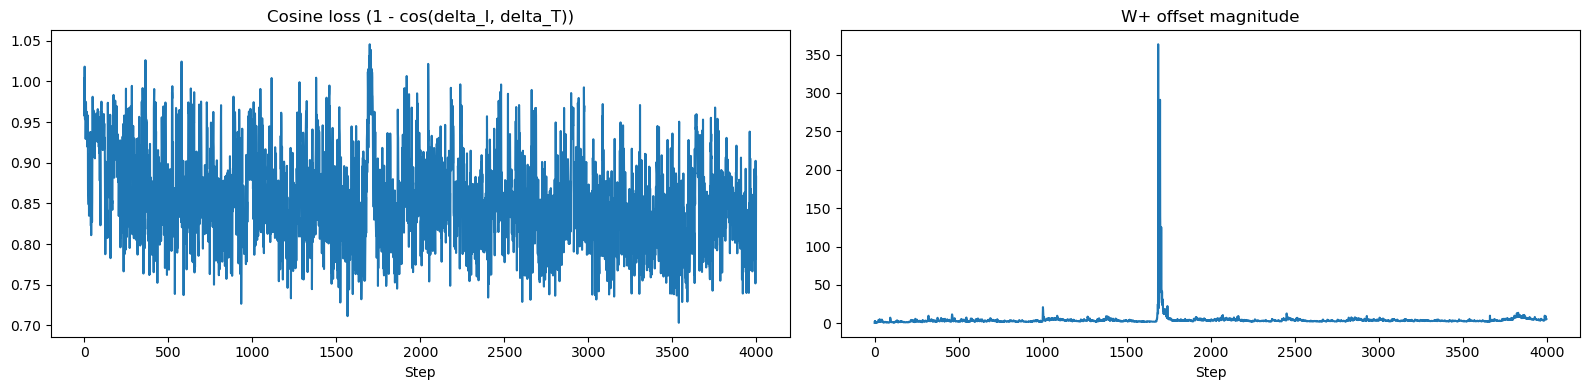

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
ax1.plot(hist_cos)
ax1.set_xlabel('Step')
ax1.set_title('Cosine loss (1 - cos(delta_I, delta_T))')
ax2.plot(hist_magn)
ax2.set_xlabel('Step')
ax2.set_title('W+ offset magnitude')
plt.tight_layout()
plt.show()

In [13]:
@torch.inference_mode()
def show_edit(seeds=(13, 25, 32, 473, 2026), truncation_psi=0.7):
    fig, axes = plt.subplots(2, len(seeds), figsize=(4 * len(seeds), 8))
    for j, s in enumerate(seeds):
        gen = torch.Generator(device).manual_seed(s)
        z = torch.randn([1, G.z_dim], generator=gen, device=device)
        wplus = G.mapping(z, None, truncation_psi=truncation_psi, update_emas=False)
        before = tensor2img(G.synthesis(wplus, noise_mode='const'))[0]
        after = tensor2img(G.synthesis(wplus + mapper(wplus), noise_mode='const'))[0]
        axes[0, j].imshow(before)
        axes[0, j].axis('off')
        axes[0, j].set_title(f'seed {s}', fontsize=10)
        axes[1, j].imshow(after)
        axes[1, j].axis('off')
    axes[0, 0].set_ylabel('original', fontsize=12)
    axes[1, 0].set_ylabel('edited', fontsize=12)
    plt.suptitle(f'\"{TEXT_BEFORE}\" -> \"{TEXT_AFTER}\"')
    plt.tight_layout()
    plt.show()

In [18]:
show_edit()

In [15]:
torch.save(mapper.state_dict(), '../checkpoints/mapper_glasses.pt')

If the edit also changes identity, raise `LAMBDA_MAGN`; if the edit is too weak to see, lower it.